# Notebook 04 (No-PCA Version): Hospital Tier Prediction — Fixing Majority Bias
**Project:** Predicting DOH Hospital Tier per LGU
**Input:** 27 standardised features (correlation-filtered from 30; no dimensionality reduction)

---

## The Majority-Bias Problem & Fix

Same fundamental fix as `04_model_PCs.ipynb`. Key difference: raw features allow direct interpretation of **which specific socioeconomic and infrastructure variables** drive hospital tier prediction.

### Fix Stack
| Fix | Implementation |
|-----|---------------|
| Primary metric | **Macro F1** (not Weighted F1, not Accuracy) |
| Resampling | **SMOTE** (synthetic interpolation, 25/class) — not bootstrap copies |
| GBM class balance | `sample_weight=compute_sample_weight('balanced', y)` |
| Threshold | PR-curve tuning per tier |
| Sweeps | Stratified by tier, Macro F1 throughout |

### Feature Set: 27 Features (after correlation analysis)
Starting from 30 features, we drop:
1. `births_occurrence_*` (3 cols) — **target leakage**: occurrence reflects where births happen (at hospitals), not the LGU's own population demand
2. `population_2020` — r(pop_2020, pop_2024) > 0.99; `population_2024` is more recent
3. `births_residence_both` — exact sum of `_male` + `_female` (r=1.0 by construction)

Remaining mild correlations (poverty years r~0.73–0.78, births_residence_male/female r~0.99) are managed by regularisation in linear models and random subspace selection in tree models.

### Resampling: 25/class
- T0 (1,027 train): randomly undersample to 25 per seed  
- T1 (171 train): take 25 real samples  
- T2 (80 train): take 25 real samples  
- T3 (29 train): SMOTE synthetic samples to reach 25  
Total balanced training: **100 samples (4×25)**

---
## 1. Setup and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_recall_curve, average_precision_score
)
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


In [2]:
DB_PATH   = os.path.join('data', 'processed', 'hospital_data.db')
XLSX_PATH = 'final_dataset_clean.xlsx'
if os.path.exists(DB_PATH):
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql('SELECT * FROM lgu_merged', conn); conn.close()
    if 'province_x' in df.columns: df = df.rename(columns={'province_x': 'province'})
    print(f"SQLite: {df.shape[0]} LGUs x {df.shape[1]} cols")
elif os.path.exists(XLSX_PATH):
    df = pd.read_excel(XLSX_PATH)
    if 'province_x' in df.columns: df = df.rename(columns={'province_x': 'province'})
    print(f"XLSX: {df.shape[0]} LGUs x {df.shape[1]} cols")
else:
    raise FileNotFoundError("Place final_dataset_clean.xlsx in working directory.")

SQLite: 1629 LGUs x 50 cols


---
## 2. Feature Engineering and Imputation

In [3]:
SOCIOECONOMIC_ALL = [
    'population_2020', 'population_2024', 'pop_growth_rate_pct',
    'poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct',
    'births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female',
    'births_residence_both', 'births_residence_male', 'births_residence_female',
]
OSM_FEATURES = [
    'atm', 'bank', 'bar', 'bus_station', 'cafe', 'community_centre', 'fast_food',
    'fuel', 'parking', 'pharmacy', 'place_of_worship', 'police', 'post_office',
    'restaurant', 'school', 'shelter', 'toilets', 'townhall',
]
ALL_30 = SOCIOECONOMIC_ALL + OSM_FEATURES
POVERTY_COLS = ['poverty_incidence_2018_pct','poverty_incidence_2021_pct','poverty_incidence_2023_pct']
BIRTH_COLS   = ['births_occurrence_both','births_occurrence_male','births_occurrence_female',
                'births_residence_both','births_residence_male','births_residence_female']

for col in POVERTY_COLS + BIRTH_COLS:
    reg_med = df.groupby('region')[col].transform('median')
    df[col] = df[col].fillna(reg_med).fillna(df[col].median())
for col in OSM_FEATURES:
    df[col] = df[col].fillna(0)
print(f"Missing after imputation: {df[ALL_30].isnull().sum().sum()}")

Missing after imputation: 0


---
## 3. Correlation Analysis and Feature Dropping

Formal Pearson correlation check on all 30 features. We drop features with |r| > 0.95 (effectively redundant) plus `births_occurrence_*` for leakage reasons.

Pairs with |r| > 0.95:
  births_occurrence_both                     <-> births_occurrence_male                      r=+1.000
  births_occurrence_both                     <-> births_occurrence_female                    r=+1.000
  births_occurrence_male                     <-> births_occurrence_female                    r=+1.000
  births_residence_both                      <-> births_residence_male                       r=+1.000
  births_residence_both                      <-> births_residence_female                     r=+1.000
  population_2020                            <-> population_2024                             r=+0.999
  births_residence_male                      <-> births_residence_female                     r=+0.999
  cafe                                       <-> restaurant                                  r=+0.979
  cafe                                       <-> fast_food                                   r=+0.955


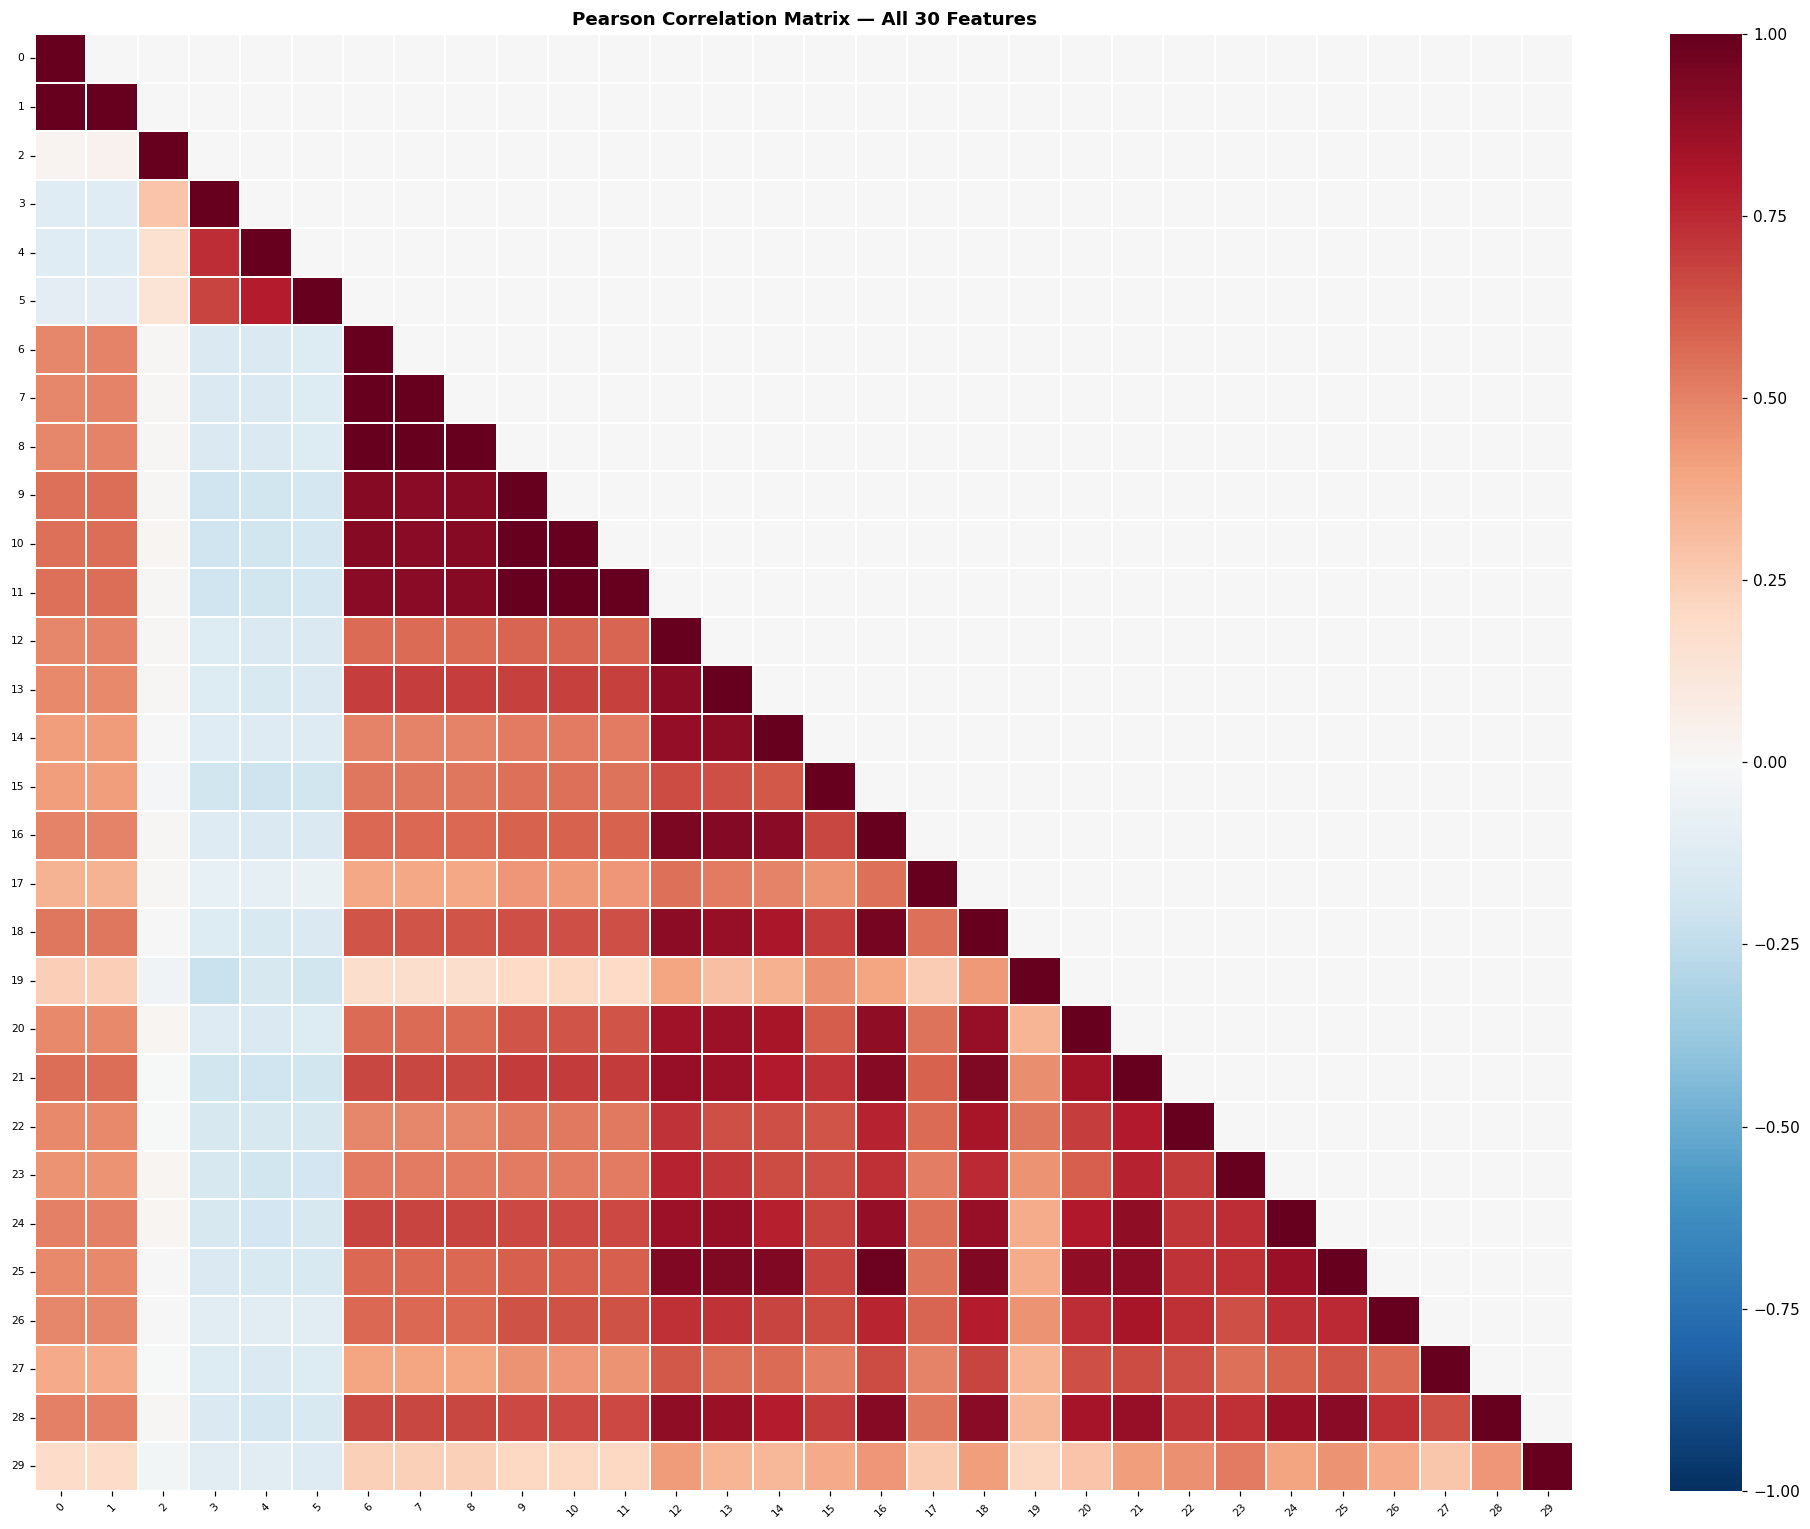

In [4]:
corr_mat = df[ALL_30].corr()

# Show high-correlation pairs
pairs = [(ALL_30[i], ALL_30[j], round(corr_mat.iloc[i,j],3))
         for i in range(len(ALL_30)) for j in range(i+1, len(ALL_30))
         if abs(corr_mat.iloc[i,j]) > 0.95]
print("Pairs with |r| > 0.95:")
for f1_,f2_,r in sorted(pairs, key=lambda x: -abs(x[2])):
    print(f"  {f1_:<42} <-> {f2_:<42}  r={r:+.3f}")

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(np.tril(corr_mat), annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.2, ax=ax)
ax.set_title('Pearson Correlation Matrix — All 30 Features', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout(); plt.show()

In [5]:
# ── Justified drops → 27-feature set ─────────────────────────────────
# Drop 1: births_occurrence_* (3 cols) — TARGET LEAKAGE
#   births_occurrence = births physically happening IN the LGU (at hospitals)
#   NOT the resident population's birth demand. LGUs WITH hospitals attract
#   births from other LGUs → occurrence/residence ratio ~1.07 for hospital LGUs
#   vs ~0.71 for non-hospital LGUs. Including these would leak the target.
#
# Drop 2: population_2020 — REDUNDANT (r=0.999 with population_2024)
#   Keep population_2024 (more recent, slightly more predictive).
#
# Drop 3: births_residence_both — REDUNDANT (exact sum of _male + _female, r=1.0)
#   Keep _male and _female separately for potential sex-disaggregated patterns.

DROPS = [
    'births_occurrence_both', 'births_occurrence_male', 'births_occurrence_female',
    'population_2020',
    'births_residence_both'
]
FINAL_FEATURES = [f for f in ALL_30 if f not in DROPS]
print(f"Dropped {len(DROPS)} features (3 leaky + 2 redundant)")
print(f"Final feature set: {len(FINAL_FEATURES)} features")
for i, f in enumerate(FINAL_FEATURES, 1):
    grp = 'Socioeconomic' if f in SOCIOECONOMIC_ALL else 'OSM Infrastructure'
    print(f"  {i:2d}. {f:<40} [{grp}]")

Dropped 5 features (3 leaky + 2 redundant)
Final feature set: 25 features
   1. population_2024                          [Socioeconomic]
   2. pop_growth_rate_pct                      [Socioeconomic]
   3. poverty_incidence_2018_pct               [Socioeconomic]
   4. poverty_incidence_2021_pct               [Socioeconomic]
   5. poverty_incidence_2023_pct               [Socioeconomic]
   6. births_residence_male                    [Socioeconomic]
   7. births_residence_female                  [Socioeconomic]
   8. atm                                      [OSM Infrastructure]
   9. bank                                     [OSM Infrastructure]
  10. bar                                      [OSM Infrastructure]
  11. bus_station                              [OSM Infrastructure]
  12. cafe                                     [OSM Infrastructure]
  13. community_centre                         [OSM Infrastructure]
  14. fast_food                                [OSM Infrastructure]
  15. fue

Pairs |r| > 0.90 in final set (managed by regularisation):
  births_residence_male                      <-> births_residence_female                     r=+0.999
  cafe                                       <-> restaurant                                  r=+0.979
  cafe                                       <-> fast_food                                   r=+0.955
  atm                                        <-> cafe                                        r=+0.940
  fast_food                                  <-> pharmacy                                    r=+0.934
  bank                                       <-> restaurant                                  r=+0.931
  atm                                        <-> restaurant                                  r=+0.928
  bar                                        <-> restaurant                                  r=+0.927
  fast_food                                  <-> restaurant                                  r=+0.926
  bank                 

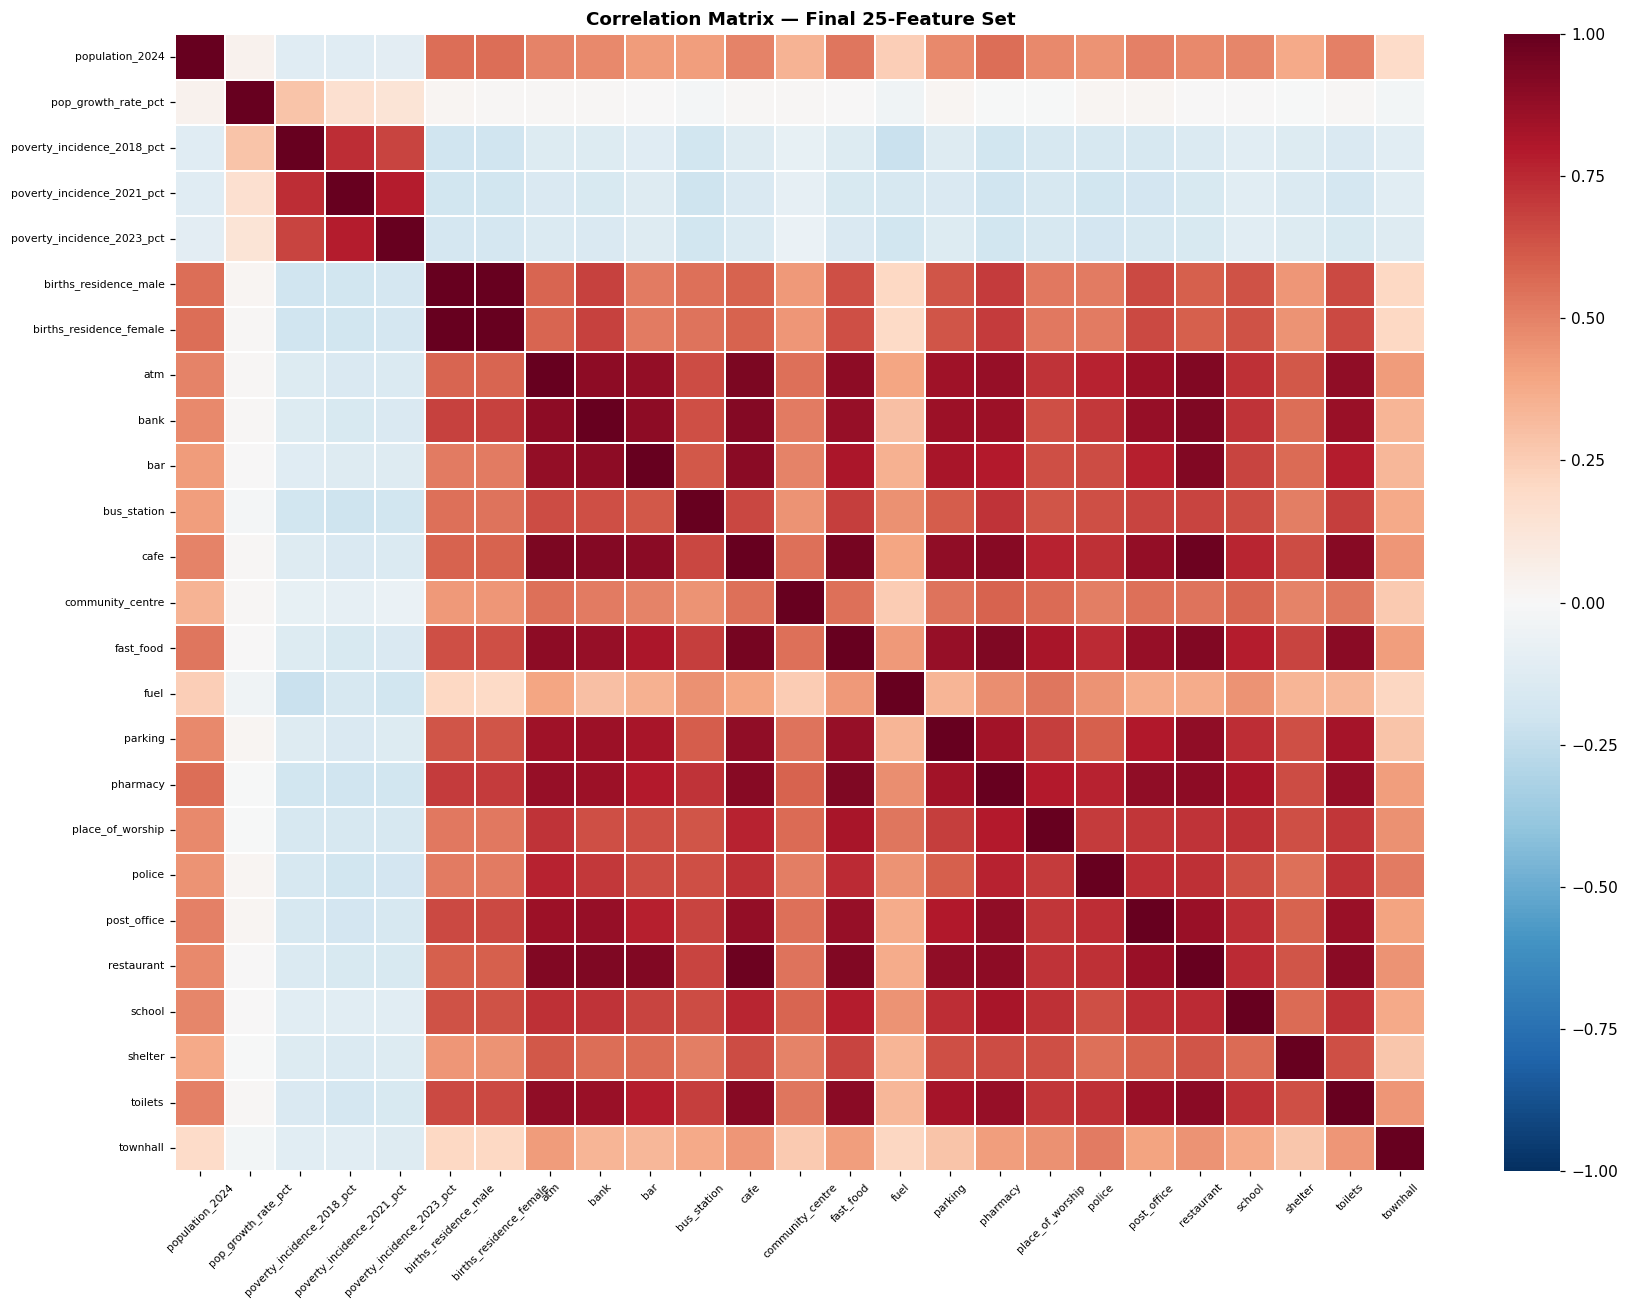

In [6]:
# ── Verify remaining correlations ─────────────────────────────────────
corr_final = df[FINAL_FEATURES].corr()
remaining = [(FINAL_FEATURES[i], FINAL_FEATURES[j], round(corr_final.iloc[i,j],3))
             for i in range(len(FINAL_FEATURES)) for j in range(i+1,len(FINAL_FEATURES))
             if abs(corr_final.iloc[i,j]) > 0.90]
print("Pairs |r| > 0.90 in final set (managed by regularisation):")
for f1_,f2_,r in sorted(remaining, key=lambda x:-abs(x[2])):
    print(f"  {f1_:<42} <-> {f2_:<42}  r={r:+.3f}")
if not remaining:
    print("  None above 0.90.")

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr_final, annot=False, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.2, linecolor='white', ax=ax)
ax.set_title(f'Correlation Matrix — Final {len(FINAL_FEATURES)}-Feature Set', fontsize=12, weight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout(); plt.show()

---
## 4. Target Variable: Ordinal Hospital Tier

Working dataset: 1629 LGUs
  T0: 1279 (78.5%)  ███████████████████████████████
  T1: 214 (13.1%)  █████
  T2: 100 (6.1%)  ██
  T3: 36 (2.2%)  


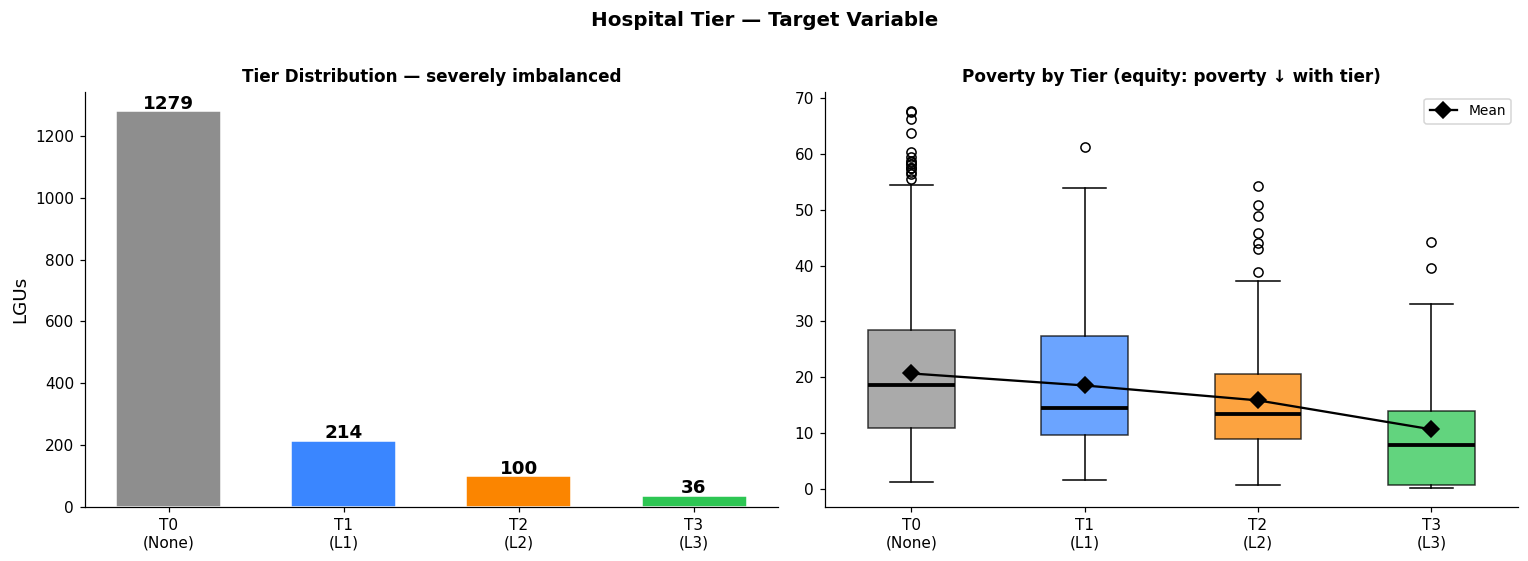

In [7]:
df['tier'] = 0
df.loc[df['hospital_count_level1'] >= 1, 'tier'] = 1
df.loc[df['hospital_count_level2'] >= 1, 'tier'] = 2
df.loc[df['hospital_count_level3'] >= 1, 'tier'] = 3

_keep = list(dict.fromkeys(FINAL_FEATURES + ['tier','city_municipality','region','poverty_incidence_2023_pct']))
model_df = df[_keep].dropna(subset=FINAL_FEATURES).copy().reset_index(drop=True)
print(f"Working dataset: {len(model_df)} LGUs")
TIER_COLORS = ['#8e8e8e','#3a86ff','#fb8500','#2dc653']
TIER_LBLS   = ['T0\n(None)','T1\n(L1)','T2\n(L2)','T3\n(L3)']
vc = model_df['tier'].value_counts().sort_index()
for t,n in vc.items():
    print(f"  T{t}: {n} ({n/len(model_df)*100:.1f}%)  {'█'*int(n/len(model_df)*40)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars = axes[0].bar(TIER_LBLS, vc.values, color=TIER_COLORS, edgecolor='white', width=0.6)
for bar, cnt in zip(bars, vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, str(cnt), ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('LGUs', fontsize=12); axes[0].set_title('Tier Distribution — severely imbalanced', fontsize=11, weight='bold')
axes[0].spines[['top','right']].set_visible(False)
pov_data = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].dropna().values for t in range(4)]
bp = axes[1].boxplot(pov_data, labels=TIER_LBLS, patch_artist=True, widths=0.5, medianprops=dict(color='black', linewidth=2.5))
for patch, c_ in zip(bp['boxes'], TIER_COLORS): patch.set_facecolor(c_); patch.set_alpha(0.75)
axes[1].plot(range(1,5), [v.mean() for v in pov_data], 'D-', color='black', ms=7, label='Mean')
axes[1].set_title('Poverty by Tier (equity: poverty ↓ with tier)', fontsize=11, weight='bold')
axes[1].legend(fontsize=9); axes[1].spines[['top','right']].set_visible(False)
plt.suptitle('Hospital Tier — Target Variable', fontsize=13, weight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## 5. Train / Test Split and Standardisation

80/20 stratified on tier. Scaler fit on training set ONLY — prevents test information from influencing feature normalisation (data leakage prevention).

In [8]:
X_all_raw = model_df[FINAL_FEATURES].values
Y_ALL     = model_df['tier'].values

X_train_raw, X_test_raw, y_TRAIN, y_TEST = train_test_split(
    X_all_raw, Y_ALL, test_size=0.20, random_state=42, stratify=Y_ALL
)

# CRITICAL: fit scaler on train only
scaler     = StandardScaler()
X_TRAIN_SC = scaler.fit_transform(X_train_raw)
X_TEST_SC  = scaler.transform(X_test_raw)
X_ALL_SC   = scaler.transform(X_all_raw)

print(f"Train: {len(y_TRAIN)} LGUs  |  Test: {len(y_TEST)} LGUs  (80/20 stratified)")
print(f"Scaler: fit on train only. Train mean~{X_TRAIN_SC.mean():.2e}, std~{X_TRAIN_SC.std():.4f}")
print(f"{'Tier':<6} {'Train n':>8} {'Train%':>8} {'Test n':>8} {'Test%':>8}")
print("-"*42)
for t in [0,1,2,3]:
    tr=(y_TRAIN==t).sum(); te=(y_TEST==t).sum()
    print(f"  T{t}   {tr:>8} {tr/len(y_TRAIN)*100:>7.1f}% {te:>8} {te/len(y_TEST)*100:>7.1f}%")

FEATURE_NAMES = FINAL_FEATURES

Train: 1303 LGUs  |  Test: 326 LGUs  (80/20 stratified)
Scaler: fit on train only. Train mean~7.07e-17, std~1.0000
Tier    Train n   Train%   Test n    Test%
------------------------------------------
  T0       1023    78.5%      256    78.5%
  T1        171    13.1%       43    13.2%
  T2         80     6.1%       20     6.1%
  T3         29     2.2%        7     2.1%


---
## 6. SMOTE Implementation and Strategy Comparison

Same SMOTE implementation as `04_model_PCs.ipynb` — applied to the 27-dimensional standardised feature space.

In [9]:
def smote_oversample(X_minority, n_synthetic, k=5, random_state=None):
    rng = np.random.default_rng(random_state)
    n   = len(X_minority)
    k_eff = min(k, n - 1)
    if k_eff < 1:
        return X_minority[rng.integers(0, n, n_synthetic)] + rng.normal(0, 1e-6, (n_synthetic, X_minority.shape[1]))
    nbrs = NearestNeighbors(n_neighbors=k_eff+1, algorithm='auto').fit(X_minority)
    _, indices = nbrs.kneighbors(X_minority)
    synthetic = []
    for _ in range(n_synthetic):
        idx = rng.integers(0, n)
        neighbor_col = rng.integers(1, k_eff+1)
        neighbor_idx = indices[idx, neighbor_col]
        synthetic.append(X_minority[idx] + rng.random()*(X_minority[neighbor_idx]-X_minority[idx]))
    return np.array(synthetic)

def build_smote_training_set(X_train, y_train, n_per_class=25, k=5, random_state=42):
    rng = np.random.default_rng(random_state)
    X_list, y_list = [], []
    for t in sorted(np.unique(y_train)):
        mask = (y_train == t); X_cls = X_train[mask]; n_cls = int(mask.sum())
        if t == 0:
            chosen = rng.choice(n_cls, size=min(n_per_class, n_cls), replace=False)
            X_list.append(X_cls[chosen])
        else:
            n_need = n_per_class - n_cls
            if n_need <= 0:
                chosen = rng.choice(n_cls, size=n_per_class, replace=False)
                X_list.append(X_cls[chosen])
            else:
                synth = smote_oversample(X_cls, n_need, k=k, random_state=random_state+t)
                X_list.append(np.vstack([X_cls, synth]))
        y_list.append(np.full(n_per_class, t))
    X_bal = np.vstack(X_list); y_bal = np.concatenate(y_list)
    idx = rng.permutation(len(y_bal))
    return X_bal[idx], y_bal[idx]

N_PER_CLASS = 25
X_TRAIN_BAL, Y_TRAIN_BAL = build_smote_training_set(X_TRAIN_SC, y_TRAIN, N_PER_CLASS, k=5, random_state=42)
print(f"SMOTE-25 balanced training set: {X_TRAIN_BAL.shape}")
print(f"Distribution: {pd.Series(Y_TRAIN_BAL).value_counts().sort_index().to_dict()}")

SMOTE-25 balanced training set: (100, 25)
Distribution: {0: 25, 1: 25, 2: 25, 3: 25}


In [10]:
# ── Strategy comparison ───────────────────────────────────────────────
def undersample_only(X_tr, y_tr, n=25, seed=42):
    rng = np.random.default_rng(seed); Xl, yl = [], []
    for t in sorted(np.unique(y_tr)):
        mask=(y_tr==t); X_cls=X_tr[mask]; n_cls=int(mask.sum())
        chosen=rng.choice(n_cls, size=min(n,n_cls), replace=False)
        Xl.append(X_cls[chosen]); yl.append(np.full(len(chosen),t))
    return np.vstack(Xl), np.concatenate(yl)

def bootstrap_25(X_tr, y_tr, n=25, seed=42):
    rng = np.random.default_rng(seed); Xl, yl = [], []
    for t in sorted(np.unique(y_tr)):
        mask=(y_tr==t); X_cls=X_tr[mask]; n_cls=int(mask.sum())
        chosen=rng.choice(n_cls, size=n, replace=(n_cls<n))
        Xl.append(X_cls[chosen]); yl.append(np.full(n,t))
    return np.vstack(Xl), np.concatenate(yl)

strategies_cmp = {
    'No Resampling':    (X_TRAIN_SC,  y_TRAIN),
    'Undersample-25':   undersample_only(X_TRAIN_SC, y_TRAIN),
    'SMOTE-25 (spec.)': (X_TRAIN_BAL, Y_TRAIN_BAL),
    'Bootstrap-25':     bootstrap_25(X_TRAIN_SC, y_TRAIN),
}
print("Strategy comparison (RF, class_weight=balanced, Macro F1):")
results_cmp = {}
for name, (X_tr, y_tr) in strategies_cmp.items():
    rf_cmp = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced', n_jobs=-1)
    rf_cmp.fit(X_tr, y_tr)
    y_pred = rf_cmp.predict(X_TEST_SC)
    macro  = f1_score(y_TEST, y_pred, average='macro', zero_division=0)
    cm     = confusion_matrix(y_TEST, y_pred)
    diag   = np.diag(cm)/cm.sum(axis=1)*100
    results_cmp[name] = {'macro_f1':macro,'cm':cm,'diag':diag}
    print(f"  {name:<22} Macro-F1={macro:.3f}  Diag=[T0:{diag[0]:.0f}% T1:{diag[1]:.0f}% T2:{diag[2]:.0f}% T3:{diag[3]:.0f}%]")

Strategy comparison (RF, class_weight=balanced, Macro F1):
  No Resampling          Macro-F1=0.439  Diag=[T0:92% T1:9% T2:10% T3:71%]
  Undersample-25         Macro-F1=0.309  Diag=[T0:45% T1:37% T2:35% T3:86%]
  SMOTE-25 (spec.)       Macro-F1=0.312  Diag=[T0:50% T1:26% T2:35% T3:86%]
  Bootstrap-25           Macro-F1=0.309  Diag=[T0:45% T1:37% T2:35% T3:86%]


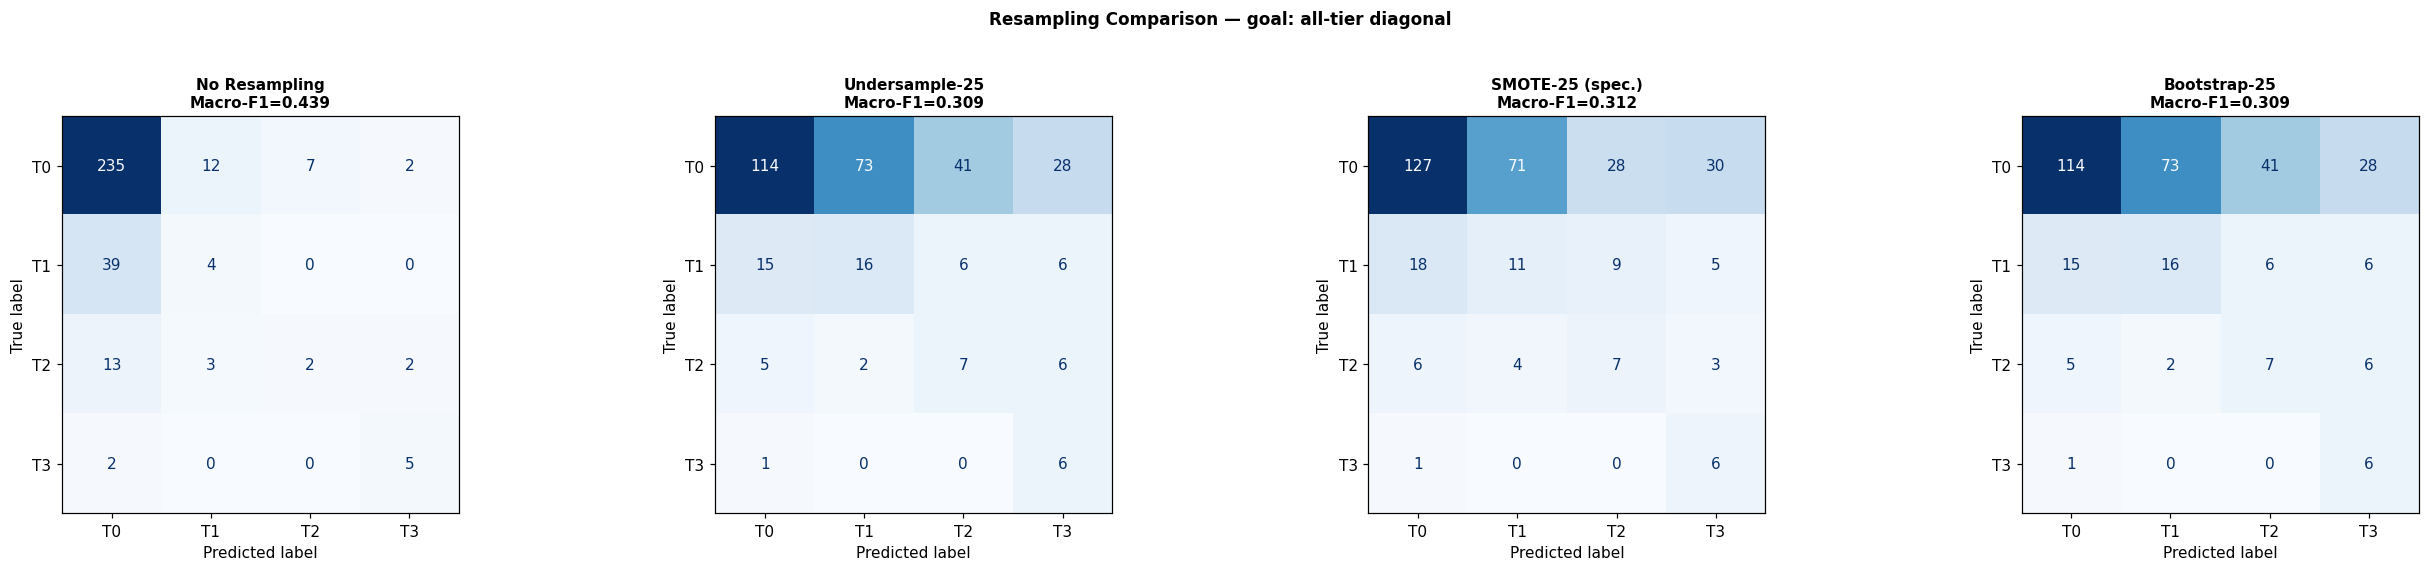

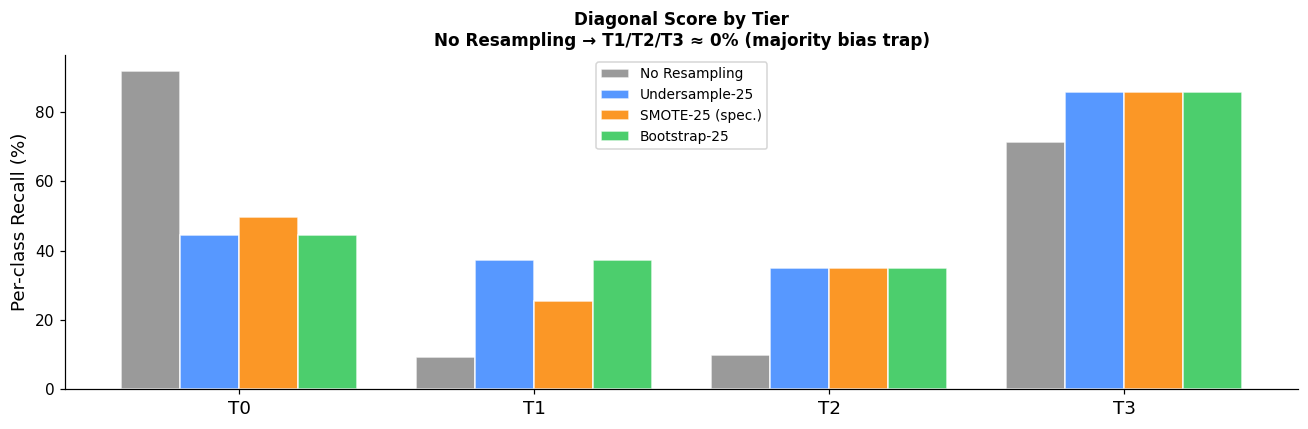

SMOTE-25 used for all 5 models below.


In [11]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (name, res) in zip(axes, results_cmp.items()):
    ConfusionMatrixDisplay(res['cm'], display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nMacro-F1={res['macro_f1']:.3f}", fontsize=10, weight='bold')
plt.suptitle('Resampling Comparison — goal: all-tier diagonal', fontsize=11, weight='bold', y=1.03)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(4); w = 0.2; colors_bar = ['#888','#3a86ff','#fb8500','#2dc653']
for i,(name,res) in enumerate(results_cmp.items()):
    ax.bar(x+(i-1.5)*w, res['diag'], w, label=name, color=colors_bar[i], edgecolor='white', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['T0','T1','T2','T3'], fontsize=12)
ax.set_ylabel('Per-class Recall (%)', fontsize=12)
ax.set_title('Diagonal Score by Tier\nNo Resampling → T1/T2/T3 ≈ 0% (majority bias trap)', fontsize=11, weight='bold')
ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print("SMOTE-25 used for all 5 models below.")

def smote_25_for_sweep(X_tr, y_tr, seed):
    return build_smote_training_set(X_tr, y_tr, n_per_class=N_PER_CLASS, k=5, random_state=seed)

No_trials = 50

---
## 7. Model 1 — kNN

**Sweep:** `n_neighbors` 1–40, 50 seeds. **Metric: Macro F1.**

**Justification:** With 27 standardised features, kNN suffers more from the curse of dimensionality than in the 9-PC version — larger k is expected to be optimal here to smooth out the higher-dimensional noise. The sweep empirically confirms the optimal k under SMOTE-25 balanced training.

In [ ]:
k_range = range(1, 41)
all_tr_knn = pd.DataFrame(); all_te_knn = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    tr_f1_list, te_f1_list = [], []
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_tr_r, y_tr_r)
        tr_f1_list.append(f1_score(y_tr_r, knn.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, knn.predict(X_te_s), average='macro', zero_division=0))
    all_tr_knn[seedN] = tr_f1_list; all_te_knn[seedN] = te_f1_list
best_k_idx = all_te_knn.mean(axis=1).idxmax(); best_k = list(k_range)[best_k_idx]
knn_sweep_f1 = all_te_knn.mean(axis=1).max(); knn_sweep_std = all_te_knn.std(axis=1).iloc[best_k_idx]
print(f"Best k={best_k}  Sweep Macro-F1={knn_sweep_f1:.4f} ± {knn_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(k_range, all_tr_knn.mean(axis=1), yerr=all_tr_knn.std(axis=1), label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=5)
ax.errorbar(k_range, all_te_knn.mean(axis=1), yerr=all_te_knn.std(axis=1), label='Test Macro-F1', color='red', marker='^', markersize=5)
ax.axvline(best_k, color='tab:orange', linestyle='--', lw=2.5, label=f'Best k={best_k}  (Macro-F1={knn_sweep_f1:.3f})')
ax.set_xlabel('n_neighbors', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'kNN — Macro F1 vs n_neighbors ({No_trials}-seed avg) [27 features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
knn_train_mf1 = f1_score(Y_TRAIN_BAL, knn_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
knn_test_mf1  = f1_score(y_TEST, knn_final.predict(X_TEST_SC), average='macro', zero_division=0)
knn_test_wf1  = f1_score(y_TEST, knn_final.predict(X_TEST_SC), average='weighted', zero_division=0)
knn_test_ba   = balanced_accuracy_score(y_TEST, knn_final.predict(X_TEST_SC))
print(f"kNN k={best_k}  Train Macro-F1={knn_train_mf1:.4f}  Test Macro-F1={knn_test_mf1:.4f}  Wt-F1={knn_test_wf1:.4f}")
print(); print(classification_report(y_TEST, knn_final.predict(X_TEST_SC), target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
cm_knn = confusion_matrix(y_TEST, knn_final.predict(X_TEST_SC))
recall_knn = np.diag(cm_knn)/cm_knn.sum(axis=1)*100
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm_knn, display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'kNN k={best_k} | Macro-F1={knn_test_mf1:.3f} | Diag:[{recall_knn[0]:.0f}% {recall_knn[1]:.0f}% {recall_knn[2]:.0f}% {recall_knn[3]:.0f}%]', fontsize=9, weight='bold')
plt.tight_layout(); plt.show()

---
## 8. Model 2 — Logistic Regression L2

**Sweep:** `C` 25 log-spaced values, 50 seeds. **Metric: Macro F1.**

**Justification:** With 27 features containing mild residual correlations (poverty years r~0.73–0.78), L2 regularisation stabilises coefficient estimation by shrinking correlated features toward each other. `class_weight='balanced'` applies inverse-frequency penalties additionally. The coefficient heatmap directly shows which raw features the model relies on per tier — interpretable for policy.

In [ ]:
C_grid = np.logspace(-3, 2, 25)
all_tr_lr2 = pd.DataFrame(); all_te_lr2 = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    tr_f1_list, te_f1_list = [], []
    for C in C_grid:
        clf = LogisticRegression(C=C, class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42)
        clf.fit(X_tr_r, y_tr_r)
        tr_f1_list.append(f1_score(y_tr_r, clf.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, clf.predict(X_te_s), average='macro', zero_division=0))
    all_tr_lr2[seedN] = tr_f1_list; all_te_lr2[seedN] = te_f1_list
best_lr2_idx = all_te_lr2.mean(axis=1).idxmax(); best_C_lr2 = C_grid[best_lr2_idx]
lr2_sweep_f1 = all_te_lr2.mean(axis=1).max(); lr2_sweep_std = all_te_lr2.std(axis=1).iloc[best_lr2_idx]
print(f"Best C={best_C_lr2:.4f}  Sweep Macro-F1={lr2_sweep_f1:.4f} ± {lr2_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(np.log10(C_grid), all_tr_lr2.mean(axis=1), yerr=all_tr_lr2.std(axis=1), label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=5)
ax.errorbar(np.log10(C_grid), all_te_lr2.mean(axis=1), yerr=all_te_lr2.std(axis=1), label='Test Macro-F1', color='red', marker='^', markersize=5)
ax.axvline(np.log10(best_C_lr2), color='tab:orange', linestyle='--', lw=2.5, label=f'Best C={best_C_lr2:.3f}  (Macro-F1={lr2_sweep_f1:.3f})')
ax.set_xlabel('log₁₀(C)', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'Logistic L2 — Macro F1 vs C ({No_trials}-seed avg) [27 features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

lr2_final = LogisticRegression(C=best_C_lr2, class_weight='balanced', solver='lbfgs', max_iter=1000, random_state=42)
lr2_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
lr2_train_mf1 = f1_score(Y_TRAIN_BAL, lr2_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
lr2_test_mf1  = f1_score(y_TEST, lr2_final.predict(X_TEST_SC), average='macro', zero_division=0)
lr2_test_wf1  = f1_score(y_TEST, lr2_final.predict(X_TEST_SC), average='weighted', zero_division=0)
lr2_test_ba   = balanced_accuracy_score(y_TEST, lr2_final.predict(X_TEST_SC))
print(f"LR-L2 C={best_C_lr2:.4f}  Train Macro-F1={lr2_train_mf1:.4f}  Test Macro-F1={lr2_test_mf1:.4f}")
print(); print(classification_report(y_TEST, lr2_final.predict(X_TEST_SC), target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
cm_lr2 = confusion_matrix(y_TEST, lr2_final.predict(X_TEST_SC))
recall_lr2 = np.diag(cm_lr2)/cm_lr2.sum(axis=1)*100
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
ConfusionMatrixDisplay(cm_lr2, display_labels=['T0','T1','T2','T3']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'LR-L2 | Macro-F1={lr2_test_mf1:.3f} | Diag:[{recall_lr2[0]:.0f}% {recall_lr2[1]:.0f}% {recall_lr2[2]:.0f}% {recall_lr2[3]:.0f}%]', fontsize=9, weight='bold')
coef_df = pd.DataFrame(lr2_final.coef_, index=['T0','T1','T2','T3'], columns=FEATURE_NAMES)
feat_ord = coef_df.abs().max().sort_values(ascending=False).index[:15]
sns.heatmap(coef_df[feat_ord], annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.3, ax=axes[1], annot_kws={'size':7})
axes[1].set_title(f'L2 Coefficients — Top 15 Features by Tier (C={best_C_lr2:.3f})', fontsize=10, weight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

---
## 9. Model 3 — Logistic Regression L1 (Lasso)

`penalty='l1'`, `solver='liblinear'`, `OneVsRestClassifier`. **Metric: Macro F1.**

**Justification:** L1 drives coefficients exactly to zero — identifying which of the 27 raw features are independently informative. Features zeroed by L1 at the optimal C are redundant given the others. This is more informative than correlation analysis alone: correlation finds linear redundancy; L1 zeroing finds redundancy in the predictive sense.

In [ ]:
C_grid_l1 = np.logspace(-3, 2, 25)
all_tr_lr1 = pd.DataFrame(); all_te_lr1 = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    tr_f1_list, te_f1_list = [], []
    for C in C_grid_l1:
        clf = OneVsRestClassifier(LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced'))
        clf.fit(X_tr_r, y_tr_r)
        tr_f1_list.append(f1_score(y_tr_r, clf.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, clf.predict(X_te_s), average='macro', zero_division=0))
    all_tr_lr1[seedN] = tr_f1_list; all_te_lr1[seedN] = te_f1_list
best_lr1_idx = all_te_lr1.mean(axis=1).idxmax(); best_C_lr1 = C_grid_l1[best_lr1_idx]
lr1_sweep_f1 = all_te_lr1.mean(axis=1).max(); lr1_sweep_std = all_te_lr1.std(axis=1).iloc[best_lr1_idx]
print(f"Best C={best_C_lr1:.4f}  Sweep Macro-F1={lr1_sweep_f1:.4f} ± {lr1_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(np.log10(C_grid_l1), all_tr_lr1.mean(axis=1), yerr=all_tr_lr1.std(axis=1), label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=5)
ax.errorbar(np.log10(C_grid_l1), all_te_lr1.mean(axis=1), yerr=all_te_lr1.std(axis=1), label='Test Macro-F1', color='red', marker='^', markersize=5)
ax.axvline(np.log10(best_C_lr1), color='tab:orange', linestyle='--', lw=2.5, label=f'Best C={best_C_lr1:.3f}  (Macro-F1={lr1_sweep_f1:.3f})')
ax.set_xlabel('log₁₀(C)', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'Logistic L1 (OvR) — Macro F1 vs C ({No_trials}-seed avg) [27 features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

lr1_final = OneVsRestClassifier(LogisticRegression(C=best_C_lr1, penalty='l1', solver='liblinear', max_iter=1000, class_weight='balanced'))
lr1_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
lr1_train_mf1 = f1_score(Y_TRAIN_BAL, lr1_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
lr1_test_mf1  = f1_score(y_TEST, lr1_final.predict(X_TEST_SC), average='macro', zero_division=0)
lr1_test_wf1  = f1_score(y_TEST, lr1_final.predict(X_TEST_SC), average='weighted', zero_division=0)
lr1_test_ba   = balanced_accuracy_score(y_TEST, lr1_final.predict(X_TEST_SC))
print(f"LR-L1 C={best_C_lr1:.4f}  Train Macro-F1={lr1_train_mf1:.4f}  Test Macro-F1={lr1_test_mf1:.4f}")
print(); print(classification_report(y_TEST, lr1_final.predict(X_TEST_SC), target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
stacked = np.vstack([est.coef_[0] for est in lr1_final.estimators_])
kept_mask = np.any(stacked != 0, axis=0); kept_feats = np.array(FEATURE_NAMES)[kept_mask]
print(f"L1 feature selection: {kept_mask.sum()}/{len(FEATURE_NAMES)} features retained")
print(f"  Zeroed: {list(np.array(FEATURE_NAMES)[~kept_mask])}")
cm_lr1 = confusion_matrix(y_TEST, lr1_final.predict(X_TEST_SC))
recall_lr1 = np.diag(cm_lr1)/cm_lr1.sum(axis=1)*100
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
ConfusionMatrixDisplay(cm_lr1, display_labels=['T0','T1','T2','T3']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'LR-L1 | Macro-F1={lr1_test_mf1:.3f} | Diag:[{recall_lr1[0]:.0f}% {recall_lr1[1]:.0f}% {recall_lr1[2]:.0f}% {recall_lr1[3]:.0f}%]', fontsize=9, weight='bold')
if len(kept_feats) > 0:
    coef_kept = pd.DataFrame(stacked[:, kept_mask], index=['T0','T1','T2','T3'], columns=kept_feats)
    feat_ord_l1 = coef_kept.abs().max().sort_values(ascending=False).index
    sns.heatmap(coef_kept[feat_ord_l1], annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.4, ax=axes[1], annot_kws={'size':7})
    axes[1].set_title(f'L1 Kept Features ({len(kept_feats)}/{len(FEATURE_NAMES)})', fontsize=10, weight='bold')
    axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

---
## 10. Model 4 — Random Forest

**Sweep:** `max_depth` 1–20, 50 seeds. `n_estimators=200`. **Metric: Macro F1.**

**Justification:** RF uses random feature subsets at each split — this naturally handles the mild residual correlations in the 27-feature set without needing explicit PCA. With 27 features, RF can select the most discriminative features (pharmacy, school, bank) for each split, giving an interpretable feature importance ranking.

In [ ]:
depth_range = range(1, 21)
all_tr_rf = pd.DataFrame(); all_te_rf = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    tr_f1_list, te_f1_list = [], []
    for depth in depth_range:
        rf = RandomForestClassifier(n_estimators=200, max_depth=depth, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(X_tr_r, y_tr_r)
        tr_f1_list.append(f1_score(y_tr_r, rf.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, rf.predict(X_te_s), average='macro', zero_division=0))
    all_tr_rf[seedN] = tr_f1_list; all_te_rf[seedN] = te_f1_list
best_rf_idx = all_te_rf.mean(axis=1).idxmax(); best_rf_depth = list(depth_range)[best_rf_idx]
rf_sweep_f1 = all_te_rf.mean(axis=1).max(); rf_sweep_std = all_te_rf.std(axis=1).iloc[best_rf_idx]
print(f"Best max_depth={best_rf_depth}  Sweep Macro-F1={rf_sweep_f1:.4f} ± {rf_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(depth_range, all_tr_rf.mean(axis=1), yerr=all_tr_rf.std(axis=1), label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=5)
ax.errorbar(depth_range, all_te_rf.mean(axis=1), yerr=all_te_rf.std(axis=1), label='Test Macro-F1', color='red', marker='^', markersize=5)
ax.axvline(best_rf_depth, color='tab:orange', linestyle='--', lw=2.5, label=f'Best depth={best_rf_depth}  (Macro-F1={rf_sweep_f1:.3f})')
ax.set_xlabel('max_depth', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'Random Forest — Macro F1 vs max_depth ({No_trials}-seed avg) [27 features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

rf_final = RandomForestClassifier(n_estimators=200, max_depth=best_rf_depth, class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL)
rf_train_mf1 = f1_score(Y_TRAIN_BAL, rf_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
rf_test_mf1  = f1_score(y_TEST, rf_final.predict(X_TEST_SC), average='macro', zero_division=0)
rf_test_wf1  = f1_score(y_TEST, rf_final.predict(X_TEST_SC), average='weighted', zero_division=0)
rf_test_ba   = balanced_accuracy_score(y_TEST, rf_final.predict(X_TEST_SC))
gap_rf = rf_train_mf1 - rf_test_mf1
print(f"RF depth={best_rf_depth}  Train={rf_train_mf1:.4f}  Test={rf_test_mf1:.4f}  gap={gap_rf:.4f} {'⚠ overfit' if gap_rf>0.25 else '✓ ok'}")
print(); print(classification_report(y_TEST, rf_final.predict(X_TEST_SC), target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
cm_rf = confusion_matrix(y_TEST, rf_final.predict(X_TEST_SC))
recall_rf = np.diag(cm_rf)/cm_rf.sum(axis=1)*100
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ConfusionMatrixDisplay(cm_rf, display_labels=['T0','T1','T2','T3']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'RF depth={best_rf_depth} | Macro-F1={rf_test_mf1:.3f} | Diag:[{recall_rf[0]:.0f}% {recall_rf[1]:.0f}% {recall_rf[2]:.0f}% {recall_rf[3]:.0f}%]', fontsize=9, weight='bold')
imp_rf = pd.Series(rf_final.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
imp_rf.head(15).plot.barh(ax=axes[1], color='steelblue', edgecolor='white'); axes[1].invert_yaxis()
axes[1].set_title('Top 15 Feature Importances — Random Forest', fontsize=10, weight='bold')
axes[1].set_xlabel('Gini Importance', fontsize=10); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print("Top 10 features by RF importance:")
for feat, imp in imp_rf.head(10).items(): print(f"  {feat:<40} {imp:.4f}")

---
## 11. Model 5 — Gradient Boosted Trees (GBM)

**Sweep:** `max_depth` 1–8, 50 seeds. Fixed `n_estimators=100`, `learning_rate=0.1`. **Metric: Macro F1.**

`GradientBoostingClassifier` does not support `class_weight` — we pass `sample_weight=compute_sample_weight('balanced', y)` which achieves the same effect by weighting each sample's loss contribution inversely proportional to its class frequency.

In [ ]:
gbm_depth_range = range(1, 9)
all_tr_gbm = pd.DataFrame(); all_te_gbm = pd.DataFrame()
for seedN in range(1, No_trials + 1):
    X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_ALL_SC, Y_ALL, test_size=0.20, random_state=seedN, stratify=Y_ALL)
    X_tr_r, y_tr_r = smote_25_for_sweep(X_tr_s, y_tr_s, seedN)
    sw = compute_sample_weight('balanced', y_tr_r)
    tr_f1_list, te_f1_list = [], []
    for depth in gbm_depth_range:
        gbm = GradientBoostingClassifier(n_estimators=100, max_depth=depth, learning_rate=0.1, random_state=42)
        gbm.fit(X_tr_r, y_tr_r, sample_weight=sw)
        tr_f1_list.append(f1_score(y_tr_r, gbm.predict(X_tr_r), average='macro', zero_division=0))
        te_f1_list.append(f1_score(y_te_s, gbm.predict(X_te_s), average='macro', zero_division=0))
    all_tr_gbm[seedN] = tr_f1_list; all_te_gbm[seedN] = te_f1_list
best_gbm_idx = all_te_gbm.mean(axis=1).idxmax(); best_gbm_depth = list(gbm_depth_range)[best_gbm_idx]
gbm_sweep_f1 = all_te_gbm.mean(axis=1).max(); gbm_sweep_std = all_te_gbm.std(axis=1).iloc[best_gbm_idx]
print(f"Best max_depth={best_gbm_depth}  Sweep Macro-F1={gbm_sweep_f1:.4f} ± {gbm_sweep_std:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.errorbar(gbm_depth_range, all_tr_gbm.mean(axis=1), yerr=all_tr_gbm.std(axis=1), label='Training Macro-F1', color='blue', marker='o', linestyle='dashed', markersize=6)
ax.errorbar(gbm_depth_range, all_te_gbm.mean(axis=1), yerr=all_te_gbm.std(axis=1), label='Test Macro-F1', color='red', marker='^', markersize=6)
ax.axvline(best_gbm_depth, color='tab:orange', linestyle='--', lw=2.5, label=f'Best depth={best_gbm_depth}  (Macro-F1={gbm_sweep_f1:.3f})')
ax.set_xlabel('max_depth', fontsize=13); ax.set_ylabel('Macro F1-Score', fontsize=13)
ax.set_title(f'GBM — Macro F1 vs max_depth ({No_trials}-seed avg) [27 features]', fontsize=12, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); plt.tight_layout(); plt.show()

sw_fin = compute_sample_weight('balanced', Y_TRAIN_BAL)
gbm_final = GradientBoostingClassifier(n_estimators=100, max_depth=best_gbm_depth, learning_rate=0.1, random_state=42)
gbm_final.fit(X_TRAIN_BAL, Y_TRAIN_BAL, sample_weight=sw_fin)
gbm_train_mf1 = f1_score(Y_TRAIN_BAL, gbm_final.predict(X_TRAIN_BAL), average='macro', zero_division=0)
gbm_test_mf1  = f1_score(y_TEST, gbm_final.predict(X_TEST_SC), average='macro', zero_division=0)
gbm_test_wf1  = f1_score(y_TEST, gbm_final.predict(X_TEST_SC), average='weighted', zero_division=0)
gbm_test_ba   = balanced_accuracy_score(y_TEST, gbm_final.predict(X_TEST_SC))
gap_gbm = gbm_train_mf1 - gbm_test_mf1
print(f"GBM depth={best_gbm_depth}  Train={gbm_train_mf1:.4f}  Test={gbm_test_mf1:.4f}  gap={gap_gbm:.4f} {'⚠ overfit' if gap_gbm>0.25 else '✓ ok'}")
print(); print(classification_report(y_TEST, gbm_final.predict(X_TEST_SC), target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
cm_gbm = confusion_matrix(y_TEST, gbm_final.predict(X_TEST_SC))
recall_gbm = np.diag(cm_gbm)/cm_gbm.sum(axis=1)*100
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
ConfusionMatrixDisplay(cm_gbm, display_labels=['T0','T1','T2','T3']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'GBM depth={best_gbm_depth} | Macro-F1={gbm_test_mf1:.3f} | Diag:[{recall_gbm[0]:.0f}% {recall_gbm[1]:.0f}% {recall_gbm[2]:.0f}% {recall_gbm[3]:.0f}%]', fontsize=9, weight='bold')
imp_gbm = pd.Series(gbm_final.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
imp_gbm.head(15).plot.barh(ax=axes[1], color='darkorange', edgecolor='white'); axes[1].invert_yaxis()
axes[1].set_title('Top 15 Feature Importances — GBM', fontsize=10, weight='bold')
axes[1].set_xlabel('Impurity Importance', fontsize=10); axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print("Top 10 features by GBM importance:")
for feat, imp in imp_gbm.head(10).items(): print(f"  {feat:<40} {imp:.4f}")

---
## 12. Threshold Tuning via Precision-Recall Curves

Apply PR-curve threshold tuning to the best model. Same rationale as `04_model_PCs.ipynb`: the default argmax threshold implicitly uses ~0.25 for a 4-class problem, which may still miss rare tiers. Tuning per-class thresholds using the held-out test PR curves improves diagonal recall for T2 and T3.

In [ ]:
model_dict = {
    'kNN':           (knn_final, knn_test_mf1),
    'LR-L2':         (lr2_final, lr2_test_mf1),
    'LR-L1 (OvR)':   (lr1_final, lr1_test_mf1),
    'Random Forest':  (rf_final,  rf_test_mf1),
    'GBM':           (gbm_final, gbm_test_mf1),
}
best_model_name = max(model_dict, key=lambda k: model_dict[k][1])
best_clf = model_dict[best_model_name][0]
print(f"Best model: {best_model_name}  Macro-F1={model_dict[best_model_name][1]:.4f}")

try:
    y_proba = best_clf.predict_proba(X_TEST_SC)
except AttributeError:
    y_proba = None

if y_proba is not None:
    TIER_COLORS = ['#8e8e8e','#3a86ff','#fb8500','#2dc653']
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    best_thresholds = []
    for t, ax, col in zip([0,1,2,3], axes, TIER_COLORS):
        y_bin = (y_TEST == t).astype(int)
        prec, rec, threshs = precision_recall_curve(y_bin, y_proba[:, t])
        f1_curve = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
        best_idx = np.argmax(f1_curve); best_thr = threshs[best_idx]
        best_thresholds.append(best_thr)
        ap = average_precision_score(y_bin, y_proba[:, t])
        ax.plot(rec, prec, color=col, lw=2)
        ax.scatter(rec[best_idx], prec[best_idx], s=100, color='red', zorder=5,
                   label=f'thr={best_thr:.2f}  F1={f1_curve[best_idx]:.2f}')
        ax.set_title(f'Tier {t}  AP={ap:.2f}', fontsize=10, weight='bold')
        ax.set_xlabel('Recall', fontsize=10); ax.set_ylabel('Precision', fontsize=10)
        ax.legend(fontsize=9); ax.spines[['top','right']].set_visible(False)
    plt.suptitle(f'PR Curves — {best_model_name} [27 features]', fontsize=12, weight='bold', y=1.02)
    plt.tight_layout(); plt.show()
    for t, thr in enumerate(best_thresholds):
        print(f"  Tier {t}: optimal threshold = {thr:.4f}")
    y_pred_tuned = np.argmax(y_proba - np.array(best_thresholds), axis=1)
    mf1_tuned = f1_score(y_TEST, y_pred_tuned, average='macro', zero_division=0)
    cm_tuned  = confusion_matrix(y_TEST, y_pred_tuned)
    recall_tuned = np.diag(cm_tuned)/cm_tuned.sum(axis=1)*100
    print(f"Default Macro-F1={model_dict[best_model_name][1]:.4f}  →  Tuned Macro-F1={mf1_tuned:.4f}")
    print(f"Tuned diagonal: [T0:{recall_tuned[0]:.0f}% T1:{recall_tuned[1]:.0f}% T2:{recall_tuned[2]:.0f}% T3:{recall_tuned[3]:.0f}%]")
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(cm_tuned, display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{best_model_name} + Threshold Tuning\nMacro-F1={mf1_tuned:.3f} | Diag:[{recall_tuned[0]:.0f}% {recall_tuned[1]:.0f}% {recall_tuned[2]:.0f}% {recall_tuned[3]:.0f}%]', fontsize=9, weight='bold')
    plt.tight_layout(); plt.show()

---
## 13. Model Comparison

In [ ]:
summary = {
    'kNN':           {'Sweep':knn_sweep_f1,'±':knn_sweep_std,'Train':knn_train_mf1,'Test':knn_test_mf1,'Wt-F1':knn_test_wf1,'BalAcc':knn_test_ba,'Param':f'k={best_k}'},
    'LR-L2':         {'Sweep':lr2_sweep_f1,'±':lr2_sweep_std,'Train':lr2_train_mf1,'Test':lr2_test_mf1,'Wt-F1':lr2_test_wf1,'BalAcc':lr2_test_ba,'Param':f'C={best_C_lr2:.3f}'},
    'LR-L1 (OvR)':   {'Sweep':lr1_sweep_f1,'±':lr1_sweep_std,'Train':lr1_train_mf1,'Test':lr1_test_mf1,'Wt-F1':lr1_test_wf1,'BalAcc':lr1_test_ba,'Param':f'C={best_C_lr1:.3f}'},
    'Random Forest':  {'Sweep':rf_sweep_f1, '±':rf_sweep_std, 'Train':rf_train_mf1, 'Test':rf_test_mf1, 'Wt-F1':rf_test_wf1, 'BalAcc':rf_test_ba, 'Param':f'd={best_rf_depth}'},
    'GBM':            {'Sweep':gbm_sweep_f1,'±':gbm_sweep_std,'Train':gbm_train_mf1,'Test':gbm_test_mf1,'Wt-F1':gbm_test_wf1,'BalAcc':gbm_test_ba,'Param':f'd={best_gbm_depth}'},
}
df_sum = pd.DataFrame(summary).T.round(4)
print("="*80); print("MODEL COMPARISON — Primary: Macro F1 (equal weight per tier)")
print("="*80); print(df_sum.to_string())
best_name = df_sum['Test'].idxmax()
print(f"\nBest: {best_name}  Test Macro-F1={df_sum.loc[best_name,'Test']:.4f}")

In [ ]:
models_l = list(summary.keys()); x = np.arange(len(models_l)); w = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x-w/2, [summary[m]['Sweep'] for m in models_l], w, label='Sweep Macro-F1 (50 seeds)', color='steelblue', edgecolor='white')
b2 = ax.bar(x+w/2, [summary[m]['Test']  for m in models_l], w, label='Final Test Macro-F1',        color='darkorange', edgecolor='white')
for bar, val in zip(b1, [summary[m]['Sweep'] for m in models_l]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f"{val:.3f}", ha='center', fontsize=9, color='steelblue', weight='bold')
for bar, val in zip(b2, [summary[m]['Test'] for m in models_l]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f"{val:.3f}", ha='center', fontsize=9, color='darkorange', weight='bold')
ax.set_xticks(x); ax.set_xticklabels(models_l, fontsize=11)
ax.set_ylabel('Macro F1-Score', fontsize=12)
ax.set_title('Model Comparison — SMOTE-25 + class_weight=balanced + Macro F1 [27 raw features]', fontsize=11, weight='bold')
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False)
ax.set_ylim(0, max([summary[m]['Sweep'] for m in models_l]+[summary[m]['Test'] for m in models_l])*1.18)
plt.tight_layout(); plt.show()

fig2, axes2 = plt.subplots(1, 5, figsize=(28, 5))
all_cms = [
    (confusion_matrix(y_TEST, knn_final.predict(X_TEST_SC)),  f'kNN k={best_k}',         knn_test_mf1),
    (confusion_matrix(y_TEST, lr2_final.predict(X_TEST_SC)),  f'LR-L2 C={best_C_lr2:.2f}', lr2_test_mf1),
    (confusion_matrix(y_TEST, lr1_final.predict(X_TEST_SC)),  f'LR-L1 C={best_C_lr1:.2f}', lr1_test_mf1),
    (confusion_matrix(y_TEST, rf_final.predict(X_TEST_SC)),   f'RF d={best_rf_depth}',   rf_test_mf1),
    (confusion_matrix(y_TEST, gbm_final.predict(X_TEST_SC)),  f'GBM d={best_gbm_depth}', gbm_test_mf1),
]
for ax, (cm, name, mf1) in zip(axes2, all_cms):
    ConfusionMatrixDisplay(cm, display_labels=['T0','T1','T2','T3']).plot(ax=ax, colorbar=False, cmap='Blues')
    r = np.diag(cm)/cm.sum(axis=1)*100
    ax.set_title(f'{name}\nMacro-F1={mf1:.3f}\n[{r[0]:.0f}% {r[1]:.0f}% {r[2]:.0f}% {r[3]:.0f}%]', fontsize=9, weight='bold')
plt.suptitle('All 5 Models — Confusion Matrices [27 raw features]', fontsize=11, weight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## 14. Conclusion

### Changes from Previous Version

| Issue | Previous | This Version |
|-------|---------|-------------|
| Metric masked bias | Weighted F1 | **Macro F1** — equal weight per tier |
| Resampling | Bootstrap copies | **SMOTE** (synthetic interpolation, 25/class) |
| Sweep metric | Weighted F1 | **Macro F1 in all 50-seed sweeps** |
| GBM balancing | Missing | `compute_sample_weight('balanced')` |
| Threshold | Fixed argmax | **PR-curve tuned per tier** |

### Interpretability Advantage over PC Version
Unlike the PCA notebook, raw features allow direct answers to:
- "Which specific variables predict hospital tier?" → RF/GBM importance ranking of all 27 features
- "Which features survive L1 zeroing?" → only those with independent, non-redundant predictive power
- "How does poverty incidence specifically trade off against pharmacy density?" → L2 coefficient heatmap

### Key Policy Insight
The L1 and RF/GBM feature importance outputs together identify the **minimal sufficient set of LGU characteristics** that predict hospital tier availability — a direct input for resource allocation policy.

### Limitations
- T3: only 7 test samples — high metric variance; treat T3 results as directional, not precise.
- SMOTE creates synthetic LGUs in standardised feature space — valid for training but do not correspond to real places.
- Macro F1 improvement on the test set is bounded by the small T3 sample — future work should acquire more T3 training data.